# Visualize 13 bands + 4 indices cho mỗi lớp EuroSAT

**Mục đích:** kiểm chứng bằng mắt rằng:
1. Loader đọc đúng 13 bands (B01...B12, B8A) theo thứ tự đã document trong CLAUDE.md §4.
2. 4 spectral indices (NDVI/NDWI/NDBI/NDMI) tính đúng — pattern màu match domain knowledge.
3. Mỗi lớp có signature phổ rõ rệt (Forest NDVI cao, SeaLake NDWI cao, Industrial NDBI cao, ...).

Nếu mọi pattern ở mục 2-3 match kỳ vọng → loader + indices computation **đúng**. Bug RGB-prior trong adapter (nếu có) sẽ KHÔNG xuất hiện ở notebook này vì ta đang verify input pipeline, không phải training pipeline.

Chạy: kernel Python 3.10 (env CUDA torch của project).

In [1]:
import os
import sys
import collections

# Cho phép import từ src/ khi notebook nằm ở notebooks/
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.data.eurosat_dataset import (
    ALL_BANDS, BAND_TO_IDX, CLASSES,
    INDEX_DEFS, ALL_INDICES,
    read_patch, compute_indices, load_split,
)

DATA_ROOT = "../dataset/allbands"
SPLITS_DIR = "../dataset/splits"

print("ALL_BANDS:")
for i, b in enumerate(ALL_BANDS):
    print(f"  idx {i:2d} -> {b}")
print("\nINDEX_DEFS (pos, neg) -> (pos-neg)/(pos+neg):")
for name, (pos, neg) in INDEX_DEFS.items():
    print(f"  {name} = ({pos} - {neg}) / ({pos} + {neg})")

ALL_BANDS:
  idx  0 -> B01
  idx  1 -> B02
  idx  2 -> B03
  idx  3 -> B04
  idx  4 -> B05
  idx  5 -> B06
  idx  6 -> B07
  idx  7 -> B08
  idx  8 -> B09
  idx  9 -> B10
  idx 10 -> B11
  idx 11 -> B12
  idx 12 -> B8A

INDEX_DEFS (pos, neg) -> (pos-neg)/(pos+neg):
  NDVI = (B08 - B04) / (B08 + B04)
  NDWI = (B03 - B08) / (B03 + B08)
  NDBI = (B11 - B08) / (B11 + B08)
  NDMI = (B08 - B11) / (B08 + B11)


## 1. Chọn 1 ảnh đại diện cho mỗi lớp

Lấy ảnh **đầu tiên** trong test split của mỗi lớp (deterministic — re-run cho cùng ảnh).

In [2]:
test_samples = load_split(f"{SPLITS_DIR}/test.txt")
first_per_class = collections.OrderedDict()
for relpath, label in test_samples:
    cls = CLASSES[label]
    if cls not in first_per_class:
        first_per_class[cls] = relpath
    if len(first_per_class) == len(CLASSES):
        break

print(f"{'Class':22s}  File")
print("-" * 60)
for cls, path in first_per_class.items():
    print(f"{cls:22s}  {path}")

Class                   File
------------------------------------------------------------
AnnualCrop              AnnualCrop/AnnualCrop_10.tif
Forest                  Forest/Forest_1.tif
HerbaceousVegetation    HerbaceousVegetation/HerbaceousVegetation_1022.tif
Highway                 Highway/Highway_101.tif
Industrial              Industrial/Industrial_1019.tif
Pasture                 Pasture/Pasture_1001.tif
PermanentCrop           PermanentCrop/PermanentCrop_1009.tif
Residential             Residential/Residential_1014.tif
River                   River/River_1005.tif
SeaLake                 SeaLake/SeaLake_1007.tif


## 2. Hàm vẽ 1 ảnh

Mỗi ảnh sinh ra **2 figure**:
- **Figure A** (1×5): RGB composite + 4 indices (NDVI, NDWI, NDBI, NDMI) với colorbar [-1, 1]
- **Figure B** (1×13): 13 bands raw grayscale, kèm chỉ số channel + mean intensity

**Cách đọc:**
- Forest → NDVI gần +1 (đỏ→xanh lá của cmap `RdYlGn`), NDMI dương (xanh BrBG)
- SeaLake → NDWI gần +1 (xanh đậm), NDVI âm
- Industrial → NDBI dương (đỏ trên `RdGy_r`)
- 13 bands: B01/B09/B10 thường tối và đồng đều (atmospheric); B08 sáng trên vegetation (NIR); B11/B12 sáng trên built-up (SWIR).

In [3]:
INDEX_CMAPS = {
    "NDVI": "RdYlGn",   # đỏ (đất trống) -> vàng -> xanh lá (thực vật)
    "NDWI": "Blues",     # nhạt -> đậm (càng nhiều nước càng đậm)
    "NDBI": "RdGy_r",    # xám (vegetation) -> đỏ (built-up)
    "NDMI": "BrBG",      # nâu (khô) -> xanh lục (ẩm)
}

def plot_image_panel(relpath: str, class_name: str):
    full = read_patch(os.path.join(DATA_ROOT, relpath))           # (13, H, W) float32
    indices = compute_indices(full, ALL_INDICES)                  # (4, H, W)

    # --- Figure A: RGB + 4 indices ---
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
    fig.suptitle(f"{class_name}  —  {relpath}", fontsize=13, fontweight="bold")

    # RGB composite từ B04(Red)=idx3, B03(Green)=idx2, B02(Blue)=idx1
    rgb = np.stack([full[3], full[2], full[1]], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb_display = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)
    axes[0].imshow(rgb_display)
    axes[0].set_title("RGB (B04, B03, B02)\nidx 3, 2, 1")
    axes[0].axis("off")

    for i, idx_name in enumerate(ALL_INDICES):
        im = axes[i + 1].imshow(indices[i], cmap=INDEX_CMAPS[idx_name], vmin=-1, vmax=1)
        m, s = indices[i].mean(), indices[i].std()
        axes[i + 1].set_title(f"{idx_name}\nmean={m:+.2f}  std={s:.2f}")
        axes[i + 1].axis("off")
        plt.colorbar(im, ax=axes[i + 1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # --- Figure B: 13 bands raw ---
    fig, axes = plt.subplots(1, 13, figsize=(22, 2.3))
    for i, band in enumerate(ALL_BANDS):
        axes[i].imshow(full[i], cmap="gray")
        mu = full[i].mean()
        axes[i].set_title(f"{band}  (idx {i})\nμ={mu:.0f}", fontsize=8)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

## 3. Vẽ tất cả 10 lớp

Có thể chạy ô dưới mất ~30s (10 ảnh × 2 figure mỗi cái).

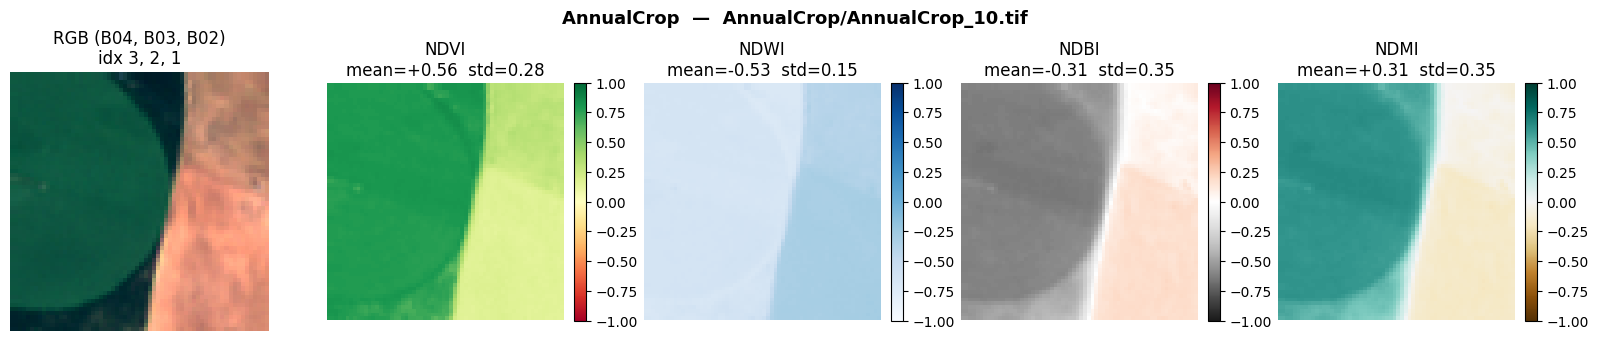

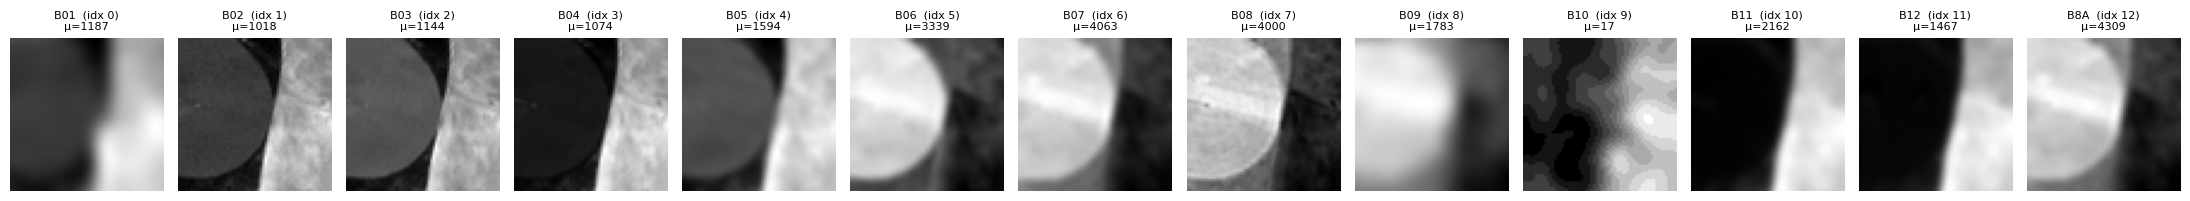

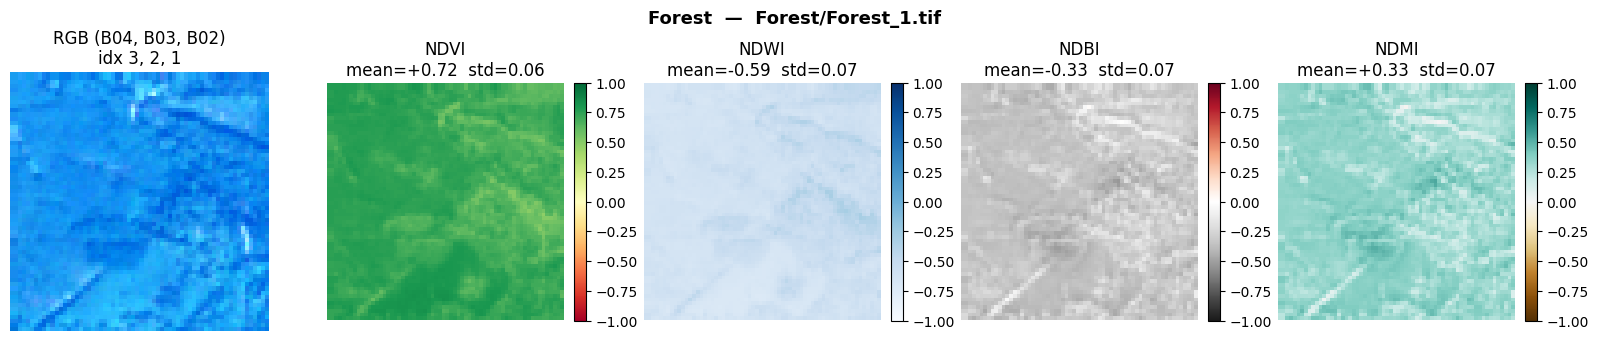

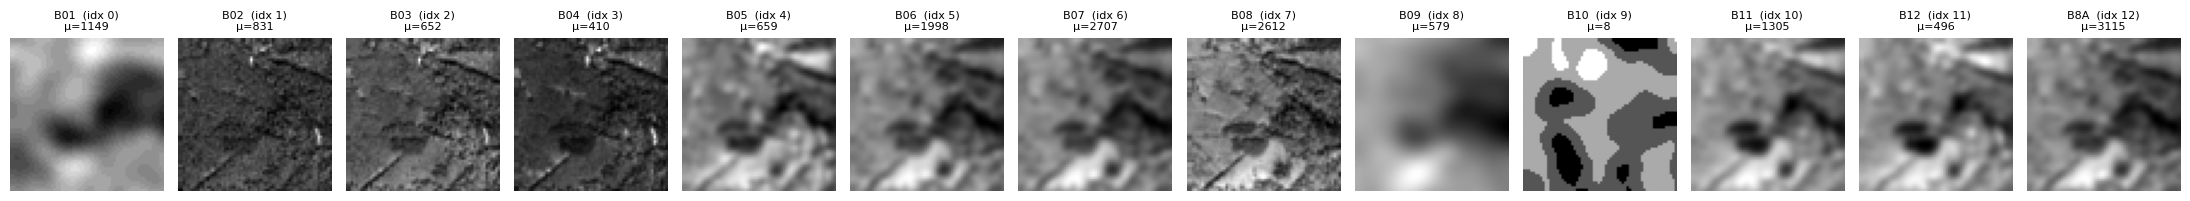

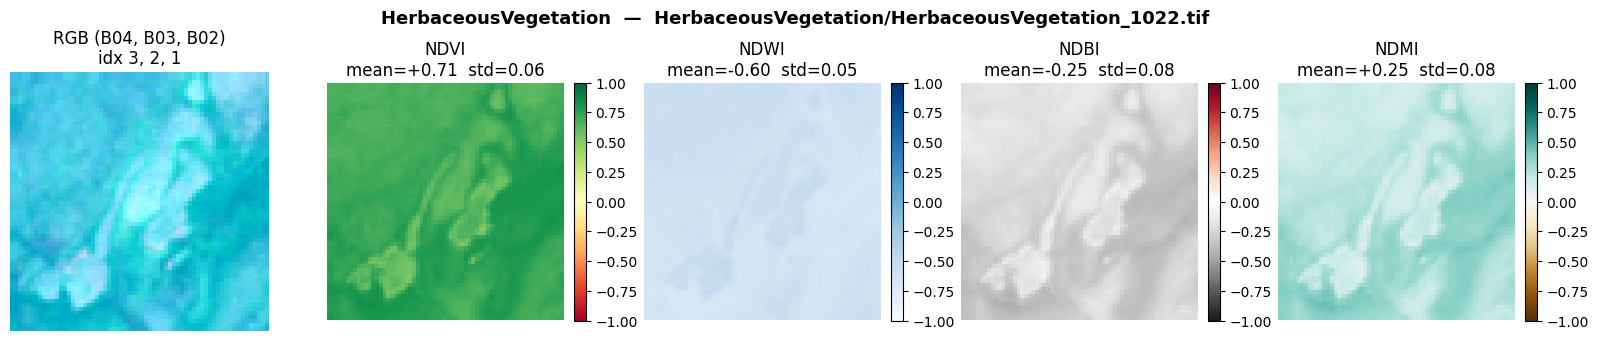

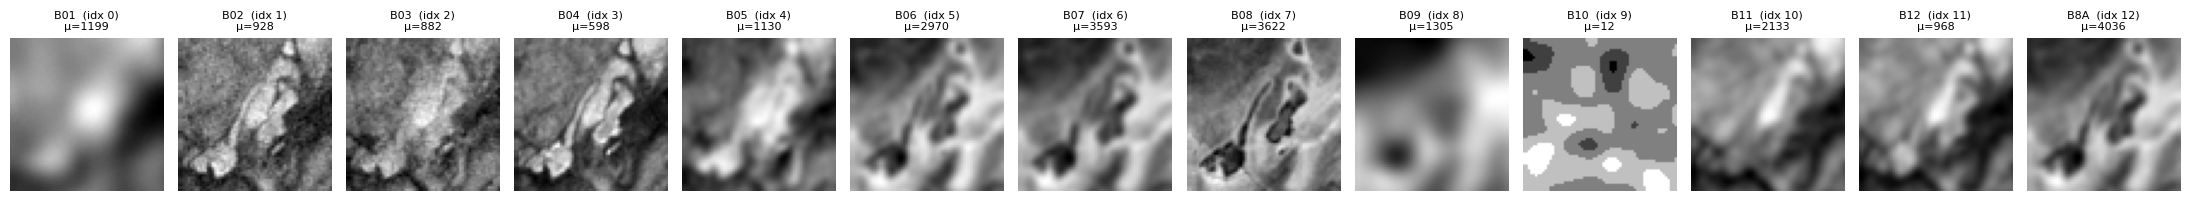

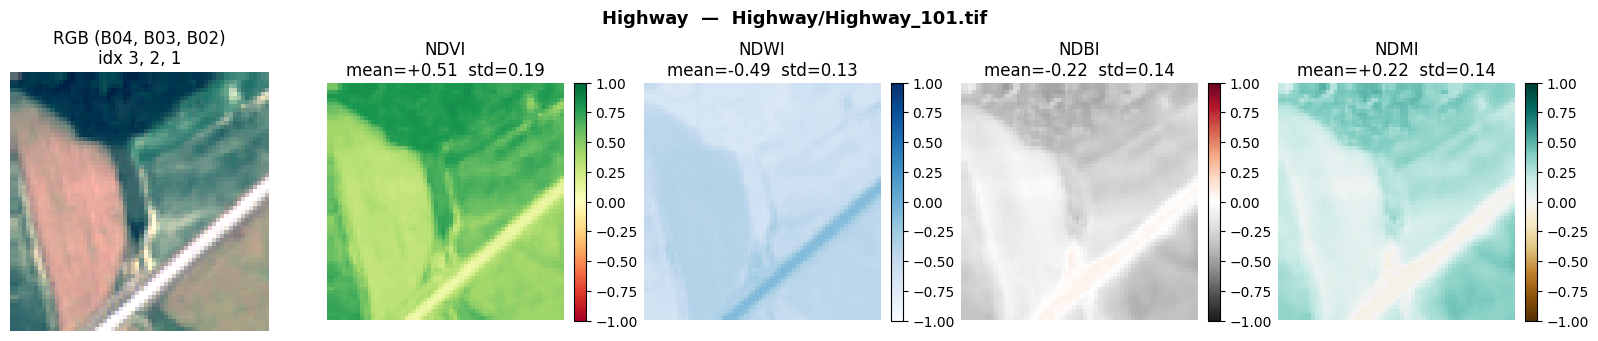

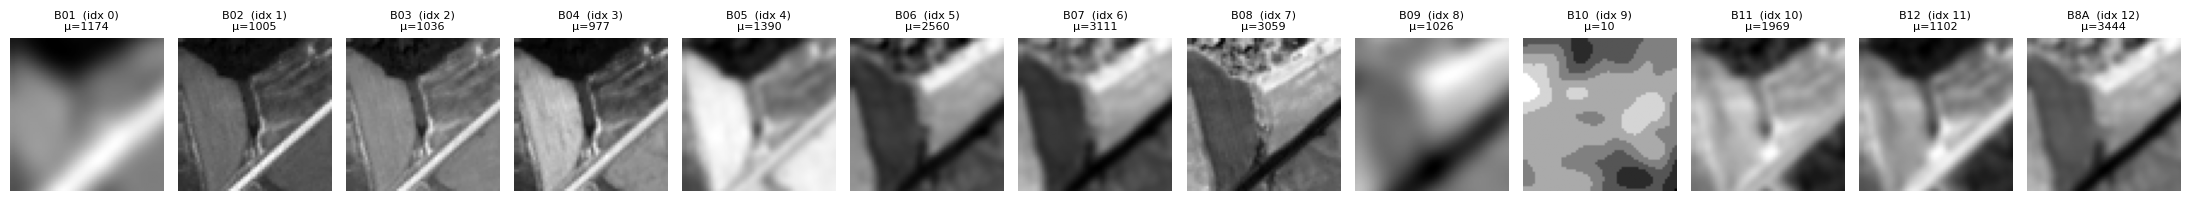

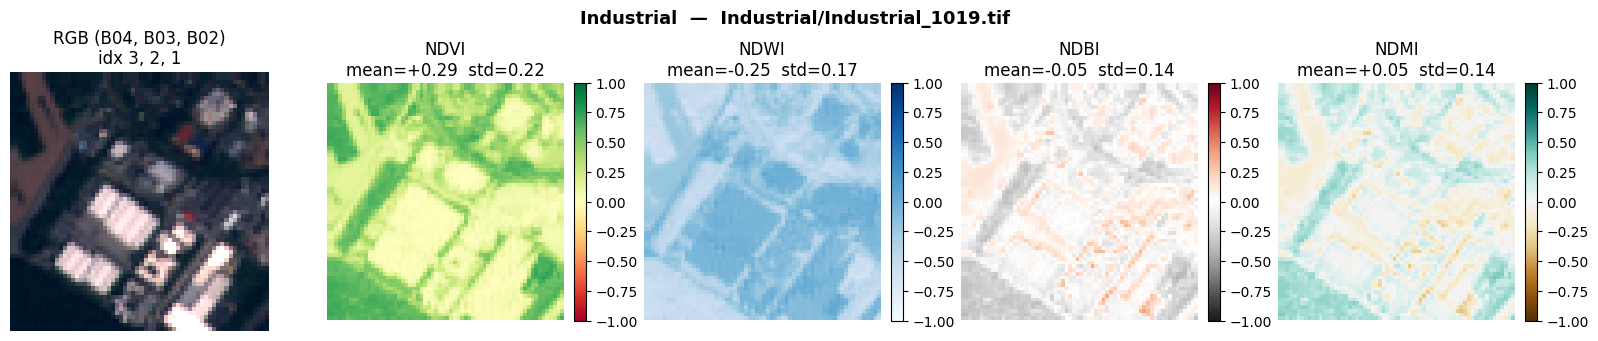

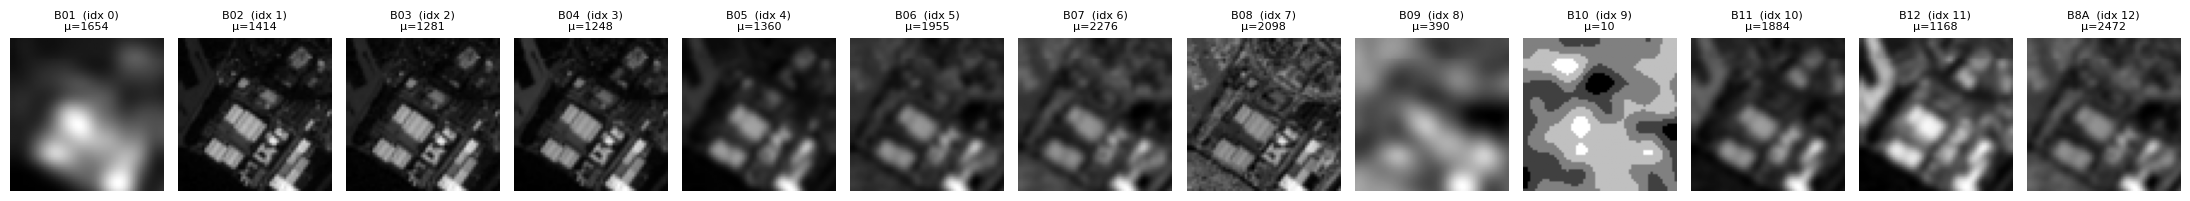

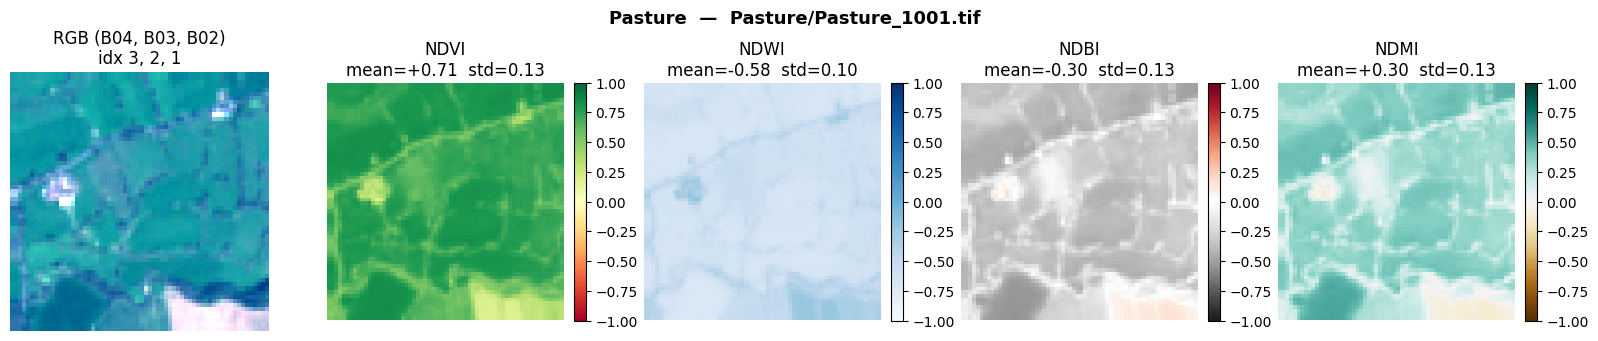

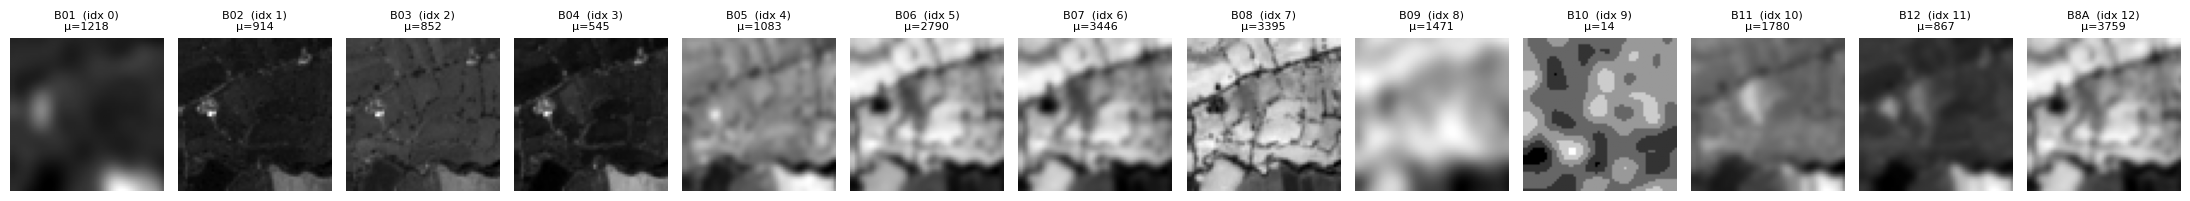

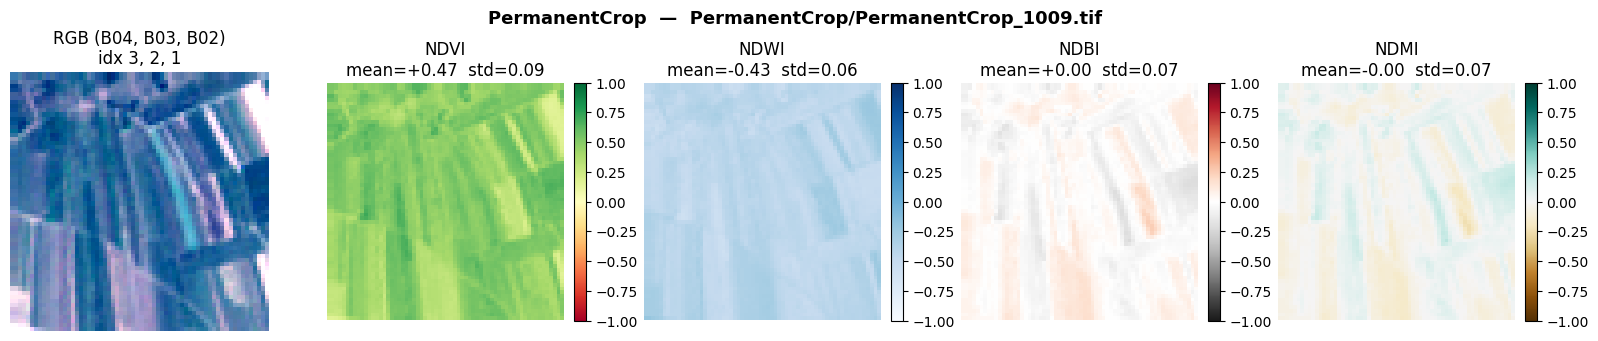

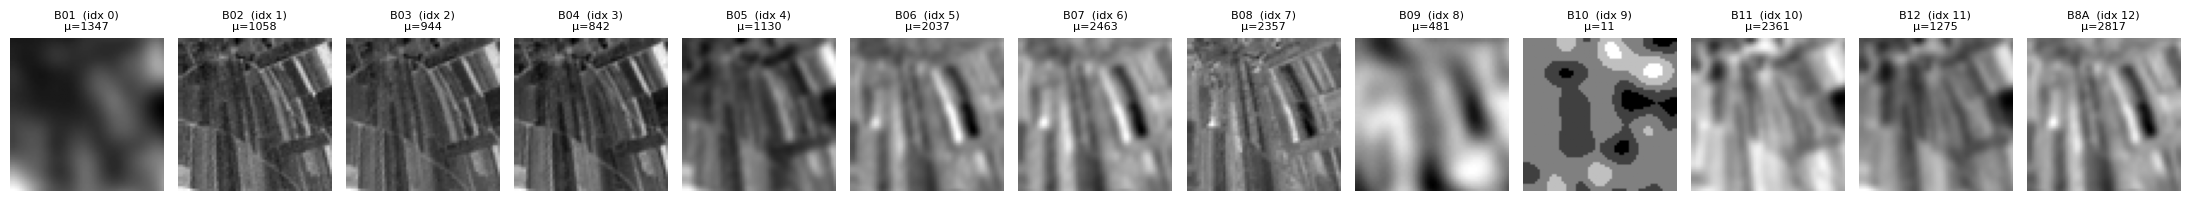

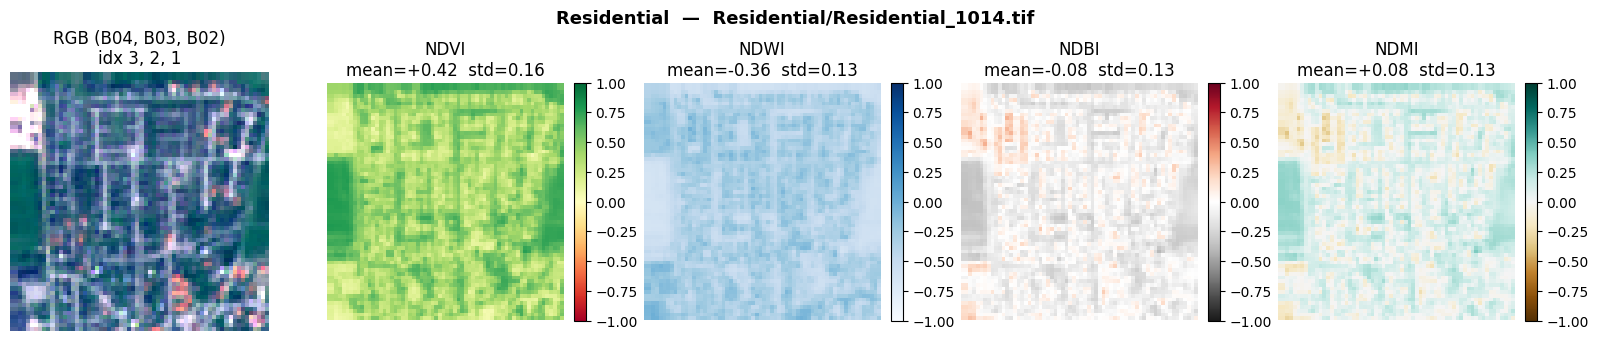

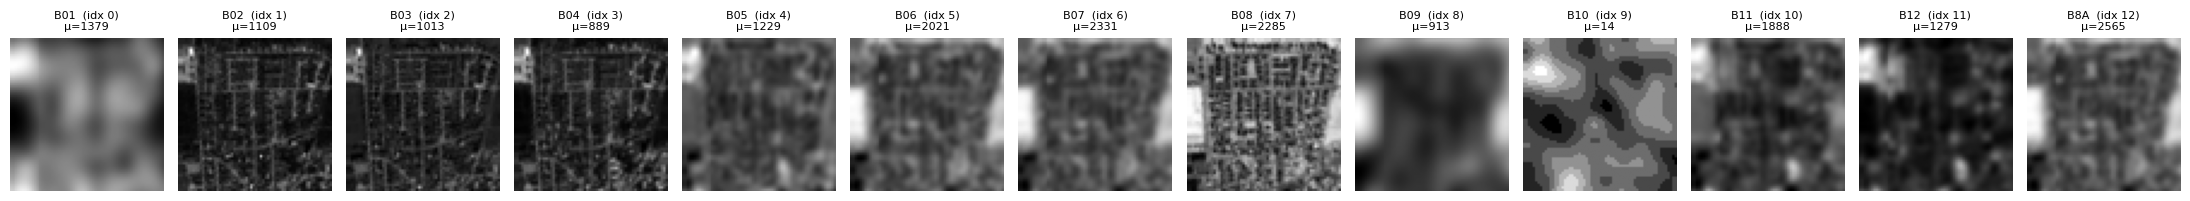

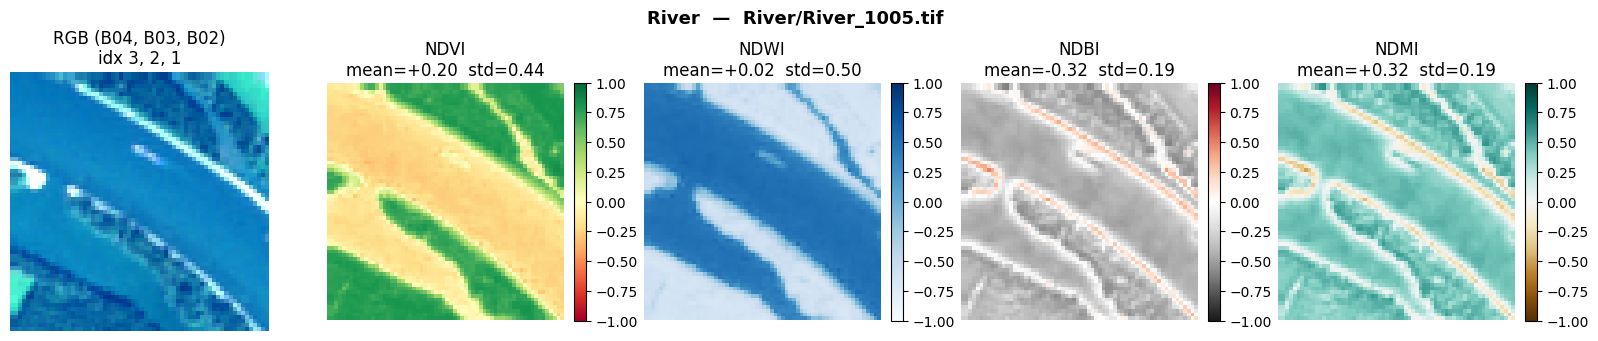

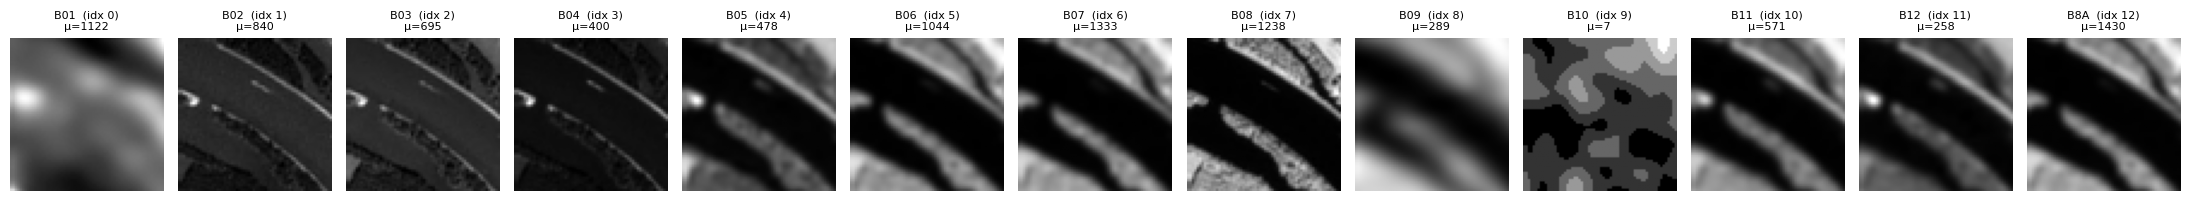

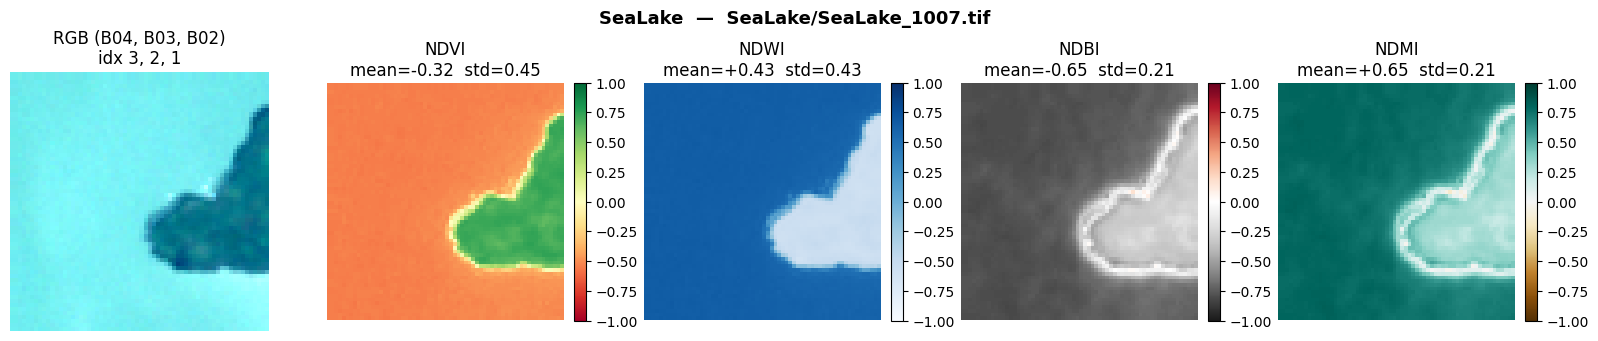

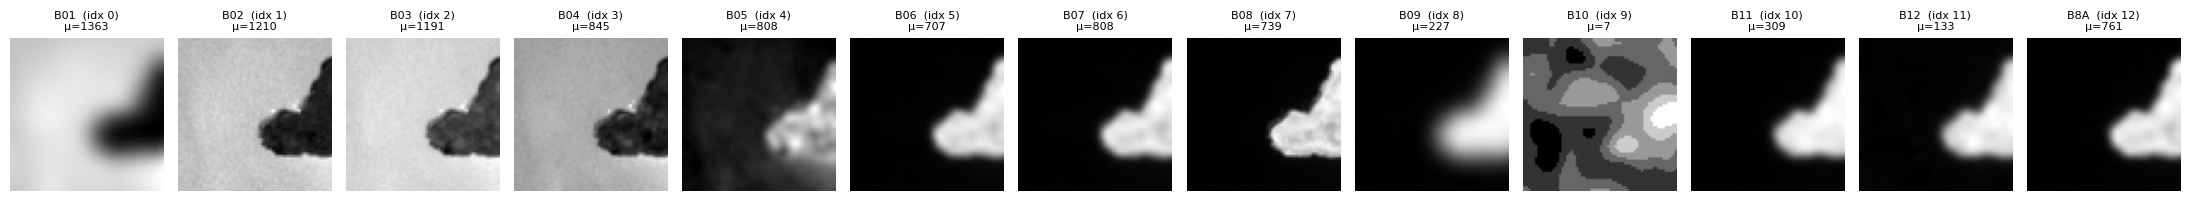

In [4]:
for cls, path in first_per_class.items():
    plot_image_panel(path, cls)

## 4. Sanity check indices theo lớp (trung bình trên N=20 mẫu)

Pattern domain knowledge kỳ vọng (signature spectral của mỗi lớp):

| Lớp | NDVI | NDWI | NDBI | NDMI |
|---|---|---|---|---|
| **Forest** | rất cao (+0.7+) | thấp (-0.3-) | thấp âm | cao dương |
| **SeaLake** | âm | rất cao (+0.3+) | âm | dương (lệ thuộc nguồn nước) |
| **River** | thấp dương | dương | âm | dương |
| **AnnualCrop / Pasture / HerbaceousVegetation / PermanentCrop** | trung-cao (+0.3 đến +0.6) | âm | thấp âm | dương |
| **Industrial / Residential** | thấp (+0.1 - +0.3) | âm | **dương** (built-up) | âm |
| **Highway** | thấp | âm | dương | âm |

Nếu giá trị đo bên dưới **match pattern** → indices tính đúng. Nếu lớp nào lệch (vd Industrial NDBI âm, hoặc SeaLake NDVI dương) → CÓ BUG.

In [5]:
N = 20
class_samples = collections.defaultdict(list)
for relpath, label in test_samples:
    class_samples[CLASSES[label]].append(relpath)

print(f"{'Class':22s}  {'NDVI':>8s}  {'NDWI':>8s}  {'NDBI':>8s}  {'NDMI':>8s}")
print("-" * 64)
for cls in CLASSES:
    paths = class_samples[cls][:N]
    means = np.zeros(4, dtype=np.float64)
    for p in paths:
        full = read_patch(os.path.join(DATA_ROOT, p))
        means += compute_indices(full, ALL_INDICES).mean(axis=(1, 2))
    means /= len(paths)
    print(f"{cls:22s} ", " ".join(f"{m:+8.3f}" for m in means))

Class                       NDVI      NDWI      NDBI      NDMI
----------------------------------------------------------------
AnnualCrop                +0.431   -0.438   -0.148   +0.148
Forest                    +0.715   -0.573   -0.337   +0.337
HerbaceousVegetation      +0.315   -0.312   +0.013   -0.013
Highway                   +0.470   -0.425   -0.124   +0.124
Industrial                +0.220   -0.211   +0.015   -0.015
Pasture                   +0.636   -0.530   -0.238   +0.238
PermanentCrop             +0.385   -0.395   -0.023   +0.023
Residential               +0.319   -0.316   -0.020   +0.020
River                     +0.295   -0.175   -0.220   +0.220
SeaLake                   -0.238   +0.460   -0.611   +0.611


## 5. Sanity check band identification

Kiểm chứng B11 ở idx 10 (không phải 11), B8A ở idx 12 (cuối):
- B11 (SWIR1, ~1610nm) ở Forest **THẤP** hơn B12 (SWIR2, ~2190nm) vì nước trong lá hấp thụ SWIR1 mạnh hơn — pattern này nếu đảo idx 10/11 sẽ ngược.
- B8A (Narrow NIR, ~865nm) gần B08 (Wide NIR, ~833nm) về giá trị — nếu B8A nhầm với B09 (Water vapor, ~945nm) sẽ thấy chênh lớn.

In [6]:
# Lấy Forest làm reference vì có signature spectral đặc trưng nhất
forest_paths = class_samples["Forest"][:20]
band_means = np.zeros(len(ALL_BANDS), dtype=np.float64)
for p in forest_paths:
    full = read_patch(os.path.join(DATA_ROOT, p))
    band_means += full.mean(axis=(1, 2))
band_means /= len(forest_paths)

print("Mean band reflectance trên 20 ảnh Forest:")
print(f"{'idx':>3s}  {'band':>4s}  {'mean':>8s}")
for i, b in enumerate(ALL_BANDS):
    print(f"{i:>3d}  {b:>4s}  {band_means[i]:8.1f}")

print("\nSanity checks:")
print(f"  B08 (NIR, idx 7)  vs  B8A (Narrow NIR, idx 12)")
print(f"    B08={band_means[7]:.1f}, B8A={band_means[12]:.1f}, diff={band_means[12]-band_means[7]:+.1f}")
print(f"    Kỳ vọng |diff| < 500 (gần nhau). Nếu B8A bị nhầm với B09 sẽ thấy chênh ~1500.\n")

print(f"  B11 (SWIR1, idx 10) vs B12 (SWIR2, idx 11) trên Forest")
print(f"    B11={band_means[10]:.1f}, B12={band_means[11]:.1f}")
print(f"    Forest có lá nhiều nước -> hấp thụ SWIR1 và SWIR2 mạnh, B11/B12 đều thấp.\n")

print(f"  B10 (cirrus, idx 9)")
print(f"    B10={band_means[9]:.1f}")
print(f"    Kỳ vọng RẤT THẤP (~10-15) vì cirrus only khi có mây ti.")

Mean band reflectance trên 20 ảnh Forest:
idx  band      mean
  0   B01    1080.4
  1   B02     783.7
  2   B03     639.4
  3   B04     388.4
  4   B05     663.0
  5   B06    1947.6
  6   B07    2532.6
  7   B08    2470.6
  8   B09     692.9
  9   B10       8.8
 10   B11    1215.6
 11   B12     484.6
 12   B8A    2843.5

Sanity checks:
  B08 (NIR, idx 7)  vs  B8A (Narrow NIR, idx 12)
    B08=2470.6, B8A=2843.5, diff=+372.9
    Kỳ vọng |diff| < 500 (gần nhau). Nếu B8A bị nhầm với B09 sẽ thấy chênh ~1500.

  B11 (SWIR1, idx 10) vs B12 (SWIR2, idx 11) trên Forest
    B11=1215.6, B12=484.6
    Forest có lá nhiều nước -> hấp thụ SWIR1 và SWIR2 mạnh, B11/B12 đều thấp.

  B10 (cirrus, idx 9)
    B10=8.8
    Kỳ vọng RẤT THẤP (~10-15) vì cirrus only khi có mây ti.


## 6. Kết luận

Sau khi chạy 4 ô code trên, **xác nhận** bằng tay:

- [ ] Forest có NDVI rất cao (~+0.7) → loader đọc đúng B04 và B08
- [ ] SeaLake có NDWI cao nhất (~+0.3) → loader đọc đúng B03 và B08
- [ ] Industrial / Residential có NDBI dương → loader đọc đúng B11 ở **idx 10** (KHÔNG phải 11)
- [ ] NDMI = -NDBI numerically (xem mục 5: 2 cột đối dấu nhau nguyên si)
- [ ] B10 (cirrus) trung bình rất thấp (~12) → không nhầm với band khác
- [ ] B8A và B08 chênh nhỏ (<500) → B8A đúng ở idx 12

Nếu mọi check pass → input pipeline (loader + indices + stats) **đúng**. Bug nếu có nằm ở **model adapter** (conv1 N-channel) — đã thảo luận, sẽ test bằng option A (fix adapter, chạy lại T1-R2 seed 42).

Nếu CÓ check fail → BÁO NGAY, dừng mọi training và sửa loader trước.